In [1]:
import config as cfg
import numpy as np
import matplotlib.pyplot as plt
from efficiency_finder import get_efficiencies, get_sample_expectations
import os
from glob import glob
import uproot
import awkward as ak
import matplotlib as mpl

In [2]:
signal_bf=1e-5
MVA1_cut = 0.994

In [3]:
folder = 'outputs/stage2'
files = {sample: glob(os.path.join(folder, sample, '*.root')) for sample in cfg.samples}

data = {}
for sample in cfg.samples:
    tree = [f'{f}:events' for f in files[sample]]
    data[sample] = uproot.concatenate(tree, expressions='EVT_MVA2', cut='(EVT_MVA1 >= 0.994) & (EVT_MVA2 >= 0.95)')['EVT_MVA2']

In [4]:
sig, bins = np.histogram(data['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu'], bins=5, range=(0.95, 1))
bb, bins  = np.histogram(data['p8_ee_Zbb_ecm91'], bins=5, range=(0.95, 1))
cc, bins  = np.histogram(data['p8_ee_Zcc_ecm91'], bins=5, range=(0.95, 1))
ss, bins  = np.histogram(data['p8_ee_Zss_ecm91'], bins=5, range=(0.95, 1))
ud, bins  = np.histogram(data['p8_ee_Zud_ecm91'], bins=5, range=(0.95, 1))

bb_err = np.sqrt(bb)
cc_err = np.sqrt(cc)
ss_err = np.sqrt(ss)
ud_err = np.sqrt(ud)
sig_err = np.sqrt(sig)

In [5]:
cut_expr = []
for i in range(len(bins)):
    if (i+1) == len(bins):
        break
    elif (i+2) == len(bins):
        cut_expr.append(f'(EVT_MVA1 >= {MVA1_cut}) & (EVT_MVA2 >= {bins[i]}) & (EVT_MVA2 <= {bins[i+1]})')
    else:
        cut_expr.append(f'(EVT_MVA1 >= {MVA1_cut}) & (EVT_MVA2 >= {bins[i]}) & (EVT_MVA2 < {bins[i+1]})')

In [6]:
effs = get_efficiencies('stage2', cut=cut_expr, raw=True, verbose=False)

In [7]:
nums = get_sample_expectations(effs, signal_bf, verbose=False, cut=cut_expr)

In [8]:
tot = np.zeros_like(nums['p8_ee_Zbb_ecm91_num'])
var = np.zeros_like(nums['p8_ee_Zbb_ecm91_err'])
for sample in cfg.samples:
    if sample in cfg.sample_allocations['background']:
        tot = tot + nums[sample+'_num']
        var = var + nums[sample+'_err']**2

tot_err = np.sqrt(var)

In [9]:
reds = mpl.colormaps['Reds_r']
cols = reds(np.linspace(0, 1, 8)[2:-2])

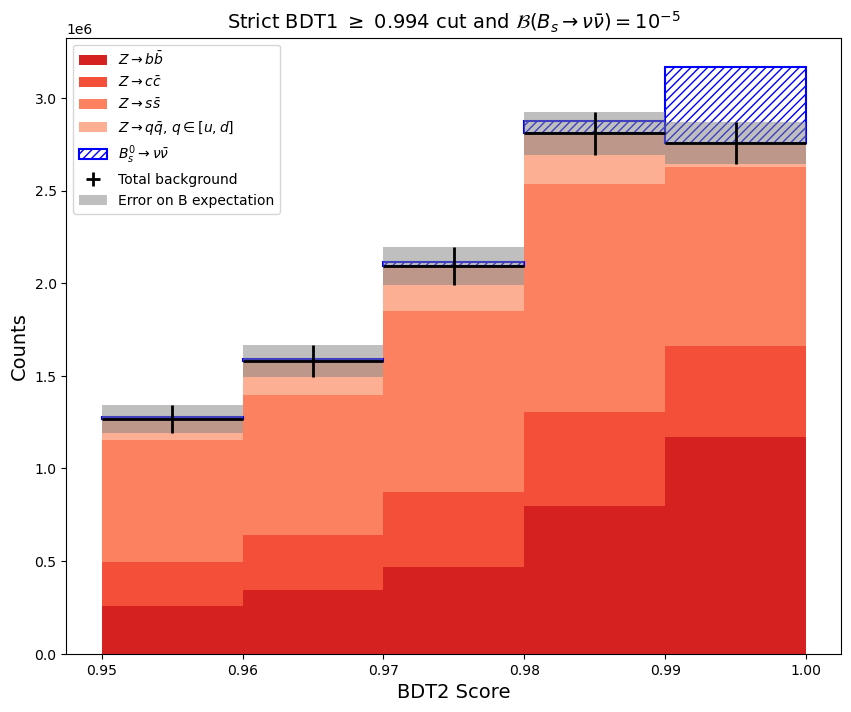

In [10]:
bin_centres = (bins[:-1]+bins[1:])/2
fig, ax = plt.subplots(figsize=(10,8))
ax.bar(bin_centres, nums['p8_ee_Zbb_ecm91_num'], width=np.diff(bins), align='center', color=cols[0], label=cfg.titles['p8_ee_Zbb_ecm91'])
ax.bar(bin_centres, nums['p8_ee_Zcc_ecm91_num'], width=np.diff(bins), align='center', color=cols[1], 
       label=cfg.titles['p8_ee_Zcc_ecm91'], bottom=nums['p8_ee_Zbb_ecm91_num'])
ax.bar(bin_centres, nums['p8_ee_Zss_ecm91_num'], width=np.diff(bins), align='center', color=cols[2], 
       label=cfg.titles['p8_ee_Zss_ecm91'], bottom=nums['p8_ee_Zbb_ecm91_num']+nums['p8_ee_Zcc_ecm91_num'])
ax.bar(bin_centres, nums['p8_ee_Zud_ecm91_num'], width=np.diff(bins), align='center', color=cols[3], 
       label=cfg.titles['p8_ee_Zud_ecm91'], bottom=nums['p8_ee_Zbb_ecm91_num']+nums['p8_ee_Zcc_ecm91_num']+nums['p8_ee_Zss_ecm91_num'])

#ax.errorbar(bin_centres, nums['p8_ee_Zbb_ecm91_num'], yerr=nums['p8_ee_Zbb_ecm91_err'], fmt='None', ecolor='black')
#ax.errorbar(bin_centres, nums['p8_ee_Zcc_ecm91_num']+nums['p8_ee_Zbb_ecm91_num'], yerr=nums['p8_ee_Zcc_ecm91_err'], fmt='None', ecolor='black')
#ax.errorbar(bin_centres, nums['p8_ee_Zcc_ecm91_num']+nums['p8_ee_Zbb_ecm91_num']+nums['p8_ee_Zss_ecm91_num'], yerr=nums['p8_ee_Zss_ecm91_err'], fmt='None', ecolor='black')
#ax.errorbar(bin_centres, nums['p8_ee_Zcc_ecm91_num']+nums['p8_ee_Zbb_ecm91_num']+nums['p8_ee_Zss_ecm91_num']+nums['p8_ee_Zud_ecm91_num'], yerr=nums['p8_ee_Zud_ecm91_err'], fmt='None', ecolor='black')

ax.bar(bin_centres, nums['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu_num'], width=np.diff(bins), align='center', 
       edgecolor='blue', hatch='////', facecolor='none', 
       linewidth=1.5, label=cfg.titles['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu'],
       bottom=tot)
ax.errorbar(bin_centres, tot, xerr=0.5*np.diff(bins), yerr=tot_err, fmt='None', ecolor='black', elinewidth=2, label='Total background')
ax.bar(bin_centres, 2*tot_err, width=np.diff(bins), align='center', color='gray', alpha=0.5, bottom=tot-tot_err, label='Error on B expectation') #from error in efficiency

ax.set_xlabel('BDT2 Score', fontsize=14)
ax.set_ylabel('Counts', fontsize=14)
ax.set_title(r'Strict BDT1 $\geq$ 0.994 cut and $\mathcal{B}(B_s\to\nu\bar{\nu}) = 10^{-5}$', fontsize=14)
ax.legend(loc='best')
#plt.savefig('/usera/rrm42/private/predict.pdf', dpi=600)
plt.show()

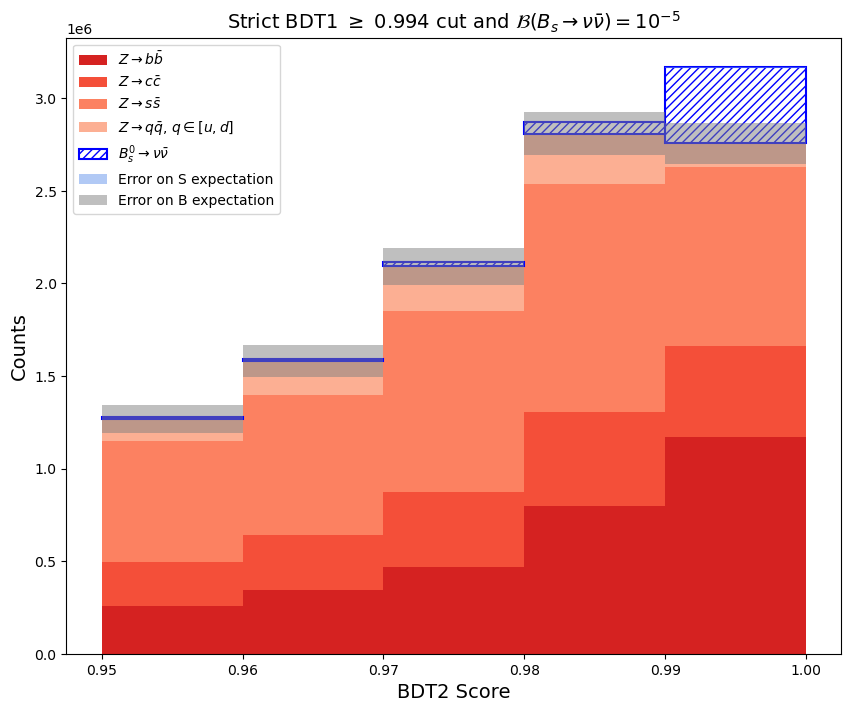

In [11]:
# Adding systematic error on signal - bnote so small that remains within lines

bin_centres = (bins[:-1]+bins[1:])/2
fig, ax = plt.subplots(figsize=(10,8))
ax.bar(bin_centres, nums['p8_ee_Zbb_ecm91_num'], width=np.diff(bins), align='center', color=cols[0], label=cfg.titles['p8_ee_Zbb_ecm91'])
ax.bar(bin_centres, nums['p8_ee_Zcc_ecm91_num'], width=np.diff(bins), align='center', color=cols[1], 
       label=cfg.titles['p8_ee_Zcc_ecm91'], bottom=nums['p8_ee_Zbb_ecm91_num'])
ax.bar(bin_centres, nums['p8_ee_Zss_ecm91_num'], width=np.diff(bins), align='center', color=cols[2], 
       label=cfg.titles['p8_ee_Zss_ecm91'], bottom=nums['p8_ee_Zbb_ecm91_num']+nums['p8_ee_Zcc_ecm91_num'])
ax.bar(bin_centres, nums['p8_ee_Zud_ecm91_num'], width=np.diff(bins), align='center', color=cols[3], 
       label=cfg.titles['p8_ee_Zud_ecm91'], bottom=nums['p8_ee_Zbb_ecm91_num']+nums['p8_ee_Zcc_ecm91_num']+nums['p8_ee_Zss_ecm91_num'])

#ax.errorbar(bin_centres, nums['p8_ee_Zbb_ecm91_num'], yerr=nums['p8_ee_Zbb_ecm91_err'], fmt='None', ecolor='black', capsize=2)
#ax.errorbar(bin_centres, nums['p8_ee_Zcc_ecm91_num']+nums['p8_ee_Zbb_ecm91_num'], yerr=nums['p8_ee_Zcc_ecm91_err'], fmt='None', ecolor='black', capsize=2)
#ax.errorbar(bin_centres, nums['p8_ee_Zcc_ecm91_num']+nums['p8_ee_Zbb_ecm91_num']+nums['p8_ee_Zss_ecm91_num'], yerr=nums['p8_ee_Zss_ecm91_err'], fmt='None', ecolor='black', capsize=2)
#ax.errorbar(bin_centres, nums['p8_ee_Zcc_ecm91_num']+nums['p8_ee_Zbb_ecm91_num']+nums['p8_ee_Zss_ecm91_num']+nums['p8_ee_Zud_ecm91_num'], yerr=nums['p8_ee_Zud_ecm91_err'], fmt='None', ecolor='black', capsize=2)

ax.bar(bin_centres, nums['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu_num'], width=np.diff(bins), align='center', 
       edgecolor='blue', hatch='////', facecolor='none', 
       linewidth=1.5, label=cfg.titles['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu'],
       bottom=tot)
#ax.errorbar(bin_centres,tot+nums['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu_num'], xerr=0.5*np.diff(bins), yerr=nums['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu_err'], fmt='None', ecolor='Blue', elinewidth=1, label='S expectation', capsize=2)
ax.bar(bin_centres, 2*nums['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu_err'], width=np.diff(bins), align='center', color='cornflowerblue', alpha=0.5, bottom=tot+nums['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu_num']-nums['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu_err'], label='Error on S expectation') #from error in efficiency


#ax.errorbar(bin_centres, tot, xerr=0.5*np.diff(bins), yerr=tot_err, fmt='None', ecolor='black', elinewidth=1, label='Total expected B', capsize=2)
ax.bar(bin_centres, 2*tot_err, width=np.diff(bins), align='center', color='gray', alpha=0.5, bottom=tot-tot_err, label='Error on B expectation') #from error in efficiency

ax.set_xlabel('BDT2 Score', fontsize=14)
ax.set_ylabel('Counts', fontsize=14)
ax.set_title(r'Strict BDT1 $\geq$ 0.994 cut and $\mathcal{B}(B_s\to\nu\bar{\nu}) = 10^{-5}$', fontsize=14)
ax.legend(loc='best')
#plt.savefig('/usera/rrm42/private/predict.pdf', dpi=600)
plt.show()

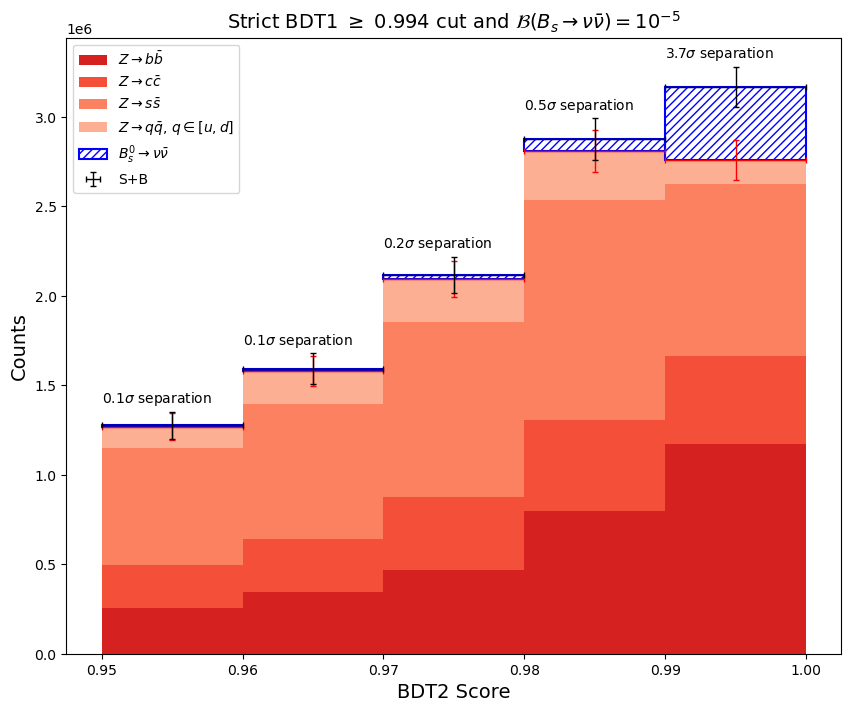

3.7412533282572795


In [15]:
#Ritwik Friday plot - encompassing efficiency error into error bar ie. sqrt{S+B+\sigma_S+\sigma_B}
S = nums['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu_num']
B = tot
sig_B = tot_err
sig_S = nums['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu_err']
full_error = np.sqrt(sig_B**2+S+B+sig_S**2)


bin_centres = (bins[:-1]+bins[1:])/2
fig, ax = plt.subplots(figsize=(10,8))
ax.bar(bin_centres, nums['p8_ee_Zbb_ecm91_num'], width=np.diff(bins), align='center', color=cols[0], label=cfg.titles['p8_ee_Zbb_ecm91'])
ax.bar(bin_centres, nums['p8_ee_Zcc_ecm91_num'], width=np.diff(bins), align='center', color=cols[1], 
       label=cfg.titles['p8_ee_Zcc_ecm91'], bottom=nums['p8_ee_Zbb_ecm91_num'])
ax.bar(bin_centres, nums['p8_ee_Zss_ecm91_num'], width=np.diff(bins), align='center', color=cols[2], 
       label=cfg.titles['p8_ee_Zss_ecm91'], bottom=nums['p8_ee_Zbb_ecm91_num']+nums['p8_ee_Zcc_ecm91_num'])
ax.bar(bin_centres, nums['p8_ee_Zud_ecm91_num'], width=np.diff(bins), align='center', color=cols[3], 
       label=cfg.titles['p8_ee_Zud_ecm91'], bottom=nums['p8_ee_Zbb_ecm91_num']+nums['p8_ee_Zcc_ecm91_num']+nums['p8_ee_Zss_ecm91_num'])


ax.bar(bin_centres,S, width=np.diff(bins), align='center', 
       edgecolor='blue', hatch='////', facecolor='none', 
       linewidth=1.5, label=cfg.titles['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu'],
       bottom=tot)

ax.errorbar(bin_centres, tot, xerr=0.5*np.diff(bins), yerr=np.sqrt(sig_B**2+B), fmt='None', ecolor='red', elinewidth=1, capsize=2)
ax.errorbar(bin_centres, S+B, xerr=0.5*np.diff(bins), yerr=full_error, fmt='None', ecolor='black', elinewidth=1, label='S+B', capsize=2)

bin_significance=S/full_error

var=0
for i in range(len(bin_centres)):
    ax.text(s=f'{round(bin_significance[i],1)}'+r'$\sigma$ separation',x=bins[i],y=S[i]+B[i]+sig_B[i]+0.05e6)
    var+= bin_significance[i]**2

ax.set_xlabel('BDT2 Score', fontsize=14)
ax.set_ylabel('Counts', fontsize=14)
ax.set_title(r'Strict BDT1 $\geq$ 0.994 cut and $\mathcal{B}(B_s\to\nu\bar{\nu}) = 10^{-5}$', fontsize=14)
ax.legend(loc='best')
plt.show()

print(np.sqrt(var))